<b>TFG: KNN</b>
    
rodrigoX: contiene 4 columnas de datos
    1. NALLParticlesTotal : Total number of particles generated by the event in the ground level.
    2. MUTotal : Total number of muons.
    3. ELTotal : Total number of electromagnetic particles.
    4. Zenith : Zenith angle of the particle [degrees].
    5. Energy : Particle energy [GeV].

rodrigoY: contiene los resultados a  predecir
    Label: photon, proton, helium, nitrogen, iron.
        the smallest number is assigned to photon (A=0) and the highest number to the heaviest particle, this is, iron (B=4).
        
        0==photon     1==proton    2==helium     3==nitrogen   4==iron 
     

In [101]:
%reset


Once deleted, variables cannot be recovered. Proceed (y/[n])? y


In [1]:
import pandas as pd
import numpy as np
import math
from scipy import stats
from collections import Counter
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sb

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
def distancia (a,b,option): #esta funcion trabaja con arrays numpy, no con escalares
    #podria hacer una distancia que le da mas peso a los puntos que estan en grupo, para eliminar outliers
    if option=='euclidea':
        d=a-b
        dist=np.sqrt(np.sum(d*d, axis=1))
    elif option=='manhattan':
        d=a-b
        dist=np.sum(np.absolute(d),axis=1)
    return dist

def KNN_np(X_train, X_test, y_train,K,choice) :   
   
    y_prueba=np.zeros(len(X_test)) #array donde almaceno las predicciones
    distancias= np.zeros(shape=(len(X_train))) #array donde almaceno las distancias
    for j in range (len(X_test)):

        posicion=np.array(X_test[j,:]) #para cada valor j de X_test
        distancias=distancia(posicion,X_train,choice)

        #lo modifico añadiendo los indices, para saber la categoria de cada x-train
        indice=np.arange(0, len(X_train))
        distancias=np.array([distancias,indice]).T

        #ahora ordeno la lista descendientemente y escojo las k-primeras columnas
        distancias=distancias[distancias[:,0].argsort()] #los ordeno segun la primera columna(o fila), tal que ya se que posiciones de x-train 
        distancias=distancias[0:K,:]                                        #son las que tienen menor distancia

        #ahora separo las distancias y sus respectivas clases
        indice_clases=np.array(distancias[:,1:2],dtype=np.int64)
        dist=distancias[:,0:1]
        
        clases= np.zeros(shape=(len(indice_clases)))
        for i in range(K):
            clases[i]=y_train[indice_clases[i]]

        #ahora veo cual es la clase que aparece mas veces
        mode = Counter(clases).most_common()#si entre parentesis pongo un 1, me dice el mas comun. Si 2, los dos mas comunes...
        pred=mode[0][0]
        if  (len(mode)>1) and (mode[0][0]==mode[1][1]): #si alguna clase se repite un igual numero de veces, miro a que clase pertenece el punto mas cercano
            pred=clases[0]

        y_prueba[j]=pred
    return y_prueba

def error(y_prueba,y_test):
    #ahora voy a proceder a calcular el error 
    error=np.zeros(len(y_test))

    #simplemente digo que si no coincide que el error sea 1---> elevarlo al cuadrado da igual
    for i in range(len(y_test)):
        if y_test[i]==y_prueba[i]:
            error[i]=0
        else:
            error[i]=1
                   #da 8340, lo que implica que ha acertado 8340 de 10498
    error_total=np.sum(error)/len(y_test)
    return (1-error_total)

def split_scale(X,y,train_perc):
    #CUIDADO!!!!!!---->https://datascience.stackexchange.com/questions/12321/difference-between-fit-and-fit-transform-in-scikit-learn-models
     
    train_size=int(train_perc*X.shape[0])
    test_size=X.shape[0]-train_size

    X_train=X[0:train_size]
    y_train=y[0:train_size]
    X_test=X[train_size:X.shape[0]]
    y_test=y[train_size:X.shape[0]]
    #X_train
    max_X_train=X_train.max()
    min_X_train=X_train.min()
    X_train=(X_train-min_X_train)/(max_X_train-min_X_train)
    #X_test
    max_X_test=X_test.max()
    min_X_test=X_test.min()
    X_test=(X_test-min_X_test)/(max_X_test-min_X_test)
    return X_train,X_test,y_train,y_test
def cv(partes,X_train,y_train,krange_inf,krange_sup,choice):
    
    split_x=np.array_split(X_train, partes) 
    split_y=np.array_split(y_train, partes) 

    #AHORA DEJO LISTO PARA METER EN LA FUNCION X-TRAIN(9 PARTES DE X-TRAIN), X-TEST(1 PARTE DE Y-TRAIN), Y-TRAIN(9 PARTES DE Y-TRAIN), Y-TEST(1 PARTE DE Y TRAIN).
    
    #He obtenido una lista de dataframes con los split, pero quiero numpy arrays
    lists_x = [ [] for i in range(partes) ] #creo una lista para almacernar cada L-fold
    lists_y = [ [] for i in range(partes) ] #creo una lista para almacernar cada L-fold

    for i in range(partes): #Pongo cada L-fold en las listas para poder trabajar con ellos
        lists_x[i]=split_x[i].values.tolist()
        lists_y[i]=split_y[i].values.tolist()
    optimo=np.empty((krange_sup-krange_inf))# array que almacena la eficacia de cada k
    contador=0
    for p in range(krange_inf,krange_sup): #lo hago para cada valor de k
        print('loop numero ',p)
        errores=np.empty((partes)) #aqui almaceno la prediccion de cada subset, para despues hacer la media
        for j in range(partes): #basicamente esto es para obtener cada subset x-train, y-train del - fold
            if j!=0:
                X_train_cv=np.array(np.array(lists_x)[0])
                y_train_cv=np.array(np.array(lists_y)[0])
                for i in range(1,partes):
                    if i!=(j):
                        #print('valor de i: ',i,', shape x_train: ',X_train_cv.shape)
                        X_train_cv=np.concatenate( ( X_train_cv, np.array(np.array(lists_x)[i]) ) , axis=0)
                        y_train_cv=np.concatenate( ( y_train_cv, np.array(np.array(lists_y)[i]) ) , axis=0)
            else:
                X_train_cv=np.array(np.array(lists_x)[1])
                y_train_cv=np.array(np.array(lists_y)[1])
                for i in range(2,partes):
                    X_train_cv=np.concatenate( ( X_train_cv, np.array(np.array(lists_x)[i]) ) , axis=0)
                    y_train_cv=np.concatenate( ( y_train_cv, np.array(np.array(lists_y)[i]) ) , axis=0)

            X_test_cv=np.array(np.array(lists_x)[j]) #subset x-test, y-test del l-fold
            y_test_cv=np.array(np.array(lists_y)[j])
            #ya tengo x-train, x-test, y-train, ahora los evaluo
            y_pred_2=KNN_np(X_train_cv, X_test_cv, y_train_cv,p,choice)
            #evaluo el error
            errores[j]=error(y_pred_2,y_test_cv) 
        optimo[contador]=errores.mean()
        contador=contador+1
    indices = np.where(optimo == optimo.max())#veo el indice(k) mas eficaz
    k_optimo= krange_inf+np.array(indices)
      
    return optimo, k_optimo

In [4]:
#cargo los datos y los barajo manualmente

dataframe = pd.read_fwf('XRodrigo.txt')
dataframe.columns = ["NALLParticlesTotal", "MUTotal", "ELTotal", "Zenith","Energy"]
dataframe_y=pd.read_fwf('YRodrigo.txt')
datay=dataframe_y.columns = ["Particle"]

transpose=dataframe.T
transpose_y=dataframe_y.T #las transpongo para poder juntarlas

dataframe_tot = transpose.append(transpose_y)
dataframe_tot=dataframe_tot.T #este el el df completo

dataframe_s = dataframe_tot.sample(frac=1).reset_index(drop=True)# barajo el dataframe

dataframe_y=dataframe_s[['Particle']]
dataframe=dataframe_s[["NALLParticlesTotal", "MUTotal", "ELTotal", "Zenith","Energy"]]

#dataframe.head(10)
#dataframe.describe()
#dataframe.info()

In [5]:
X = dataframe
y = dataframe_y
X_train,X_test,y_train,y_test=split_scale(X,y,0.75)
#por si tengo que usarlos
X_train_np=X_train.to_numpy() #pongo X_train en numpy para trabajar con el 
X_test_np=X_test.to_numpy() #pongo X_test en numpy para trabajar con el 
y_train_np=y_train.to_numpy() #pongo y_train en numpy para trabajar con el
y_test_np=y_test.to_numpy() #pongo y_train en numpy para trabajar con el

In [6]:
#hago cross-validation
optimo, k_optimo=cv(10,X_train,y_train,7,8,'euclidea')

loop numero  7


In [7]:
#veo el k optimo obtenido
optimo

array([0.72346314])

In [8]:
#EVALUO UN K PARTICULAR SIN HACER CV, CON EL TEST DATA
X_train_np=X_train.to_numpy() #pongo X_train en numpy para trabajar con el 
X_test_np=X_test.to_numpy() #pongo X_test en numpy para trabajar con el 
y_train_np=y_train.to_numpy() #pongo y_train en numpy para trabajar con el    
y_prueba=KNN_np(X_train_np, X_test_np, y_train_np,6,'euclidea')

y_prueba_np=np.array(y_prueba)
y_test_np=y_test.to_numpy().reshape(len(y_test))
acierto=error(y_prueba,y_test_np) 
acierto

0.7292817679558011

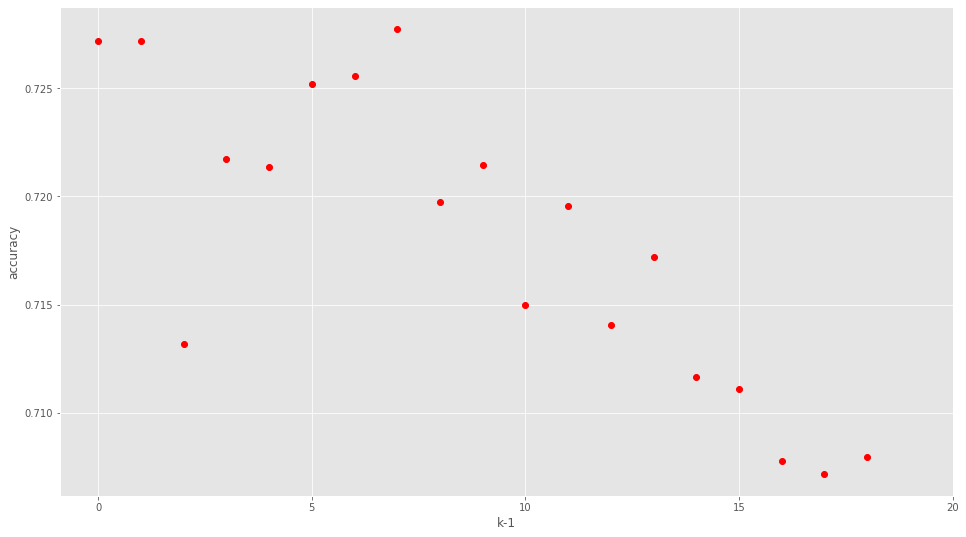

In [9]:
#hago la grafica para k (sin ser CV)
k_values=[0.72718613, 0.72718613, 0.71318346, 0.72175653, 0.7213755 , 0.72518575, 0.72556677, 0.72775767, 0.71975614, 0.72147076, 0.71499333, 0.71956563, 0.71404077, 0.71718423, 0.71165936, 0.71108783, 0.70775386, 0.70718232, 0.70794437]
plt.plot(k_values,'ro')
plt.ylabel('accuracy')
plt.xlabel('k-1')
plt.xticks([0,5,10,15,20])
plt.show()

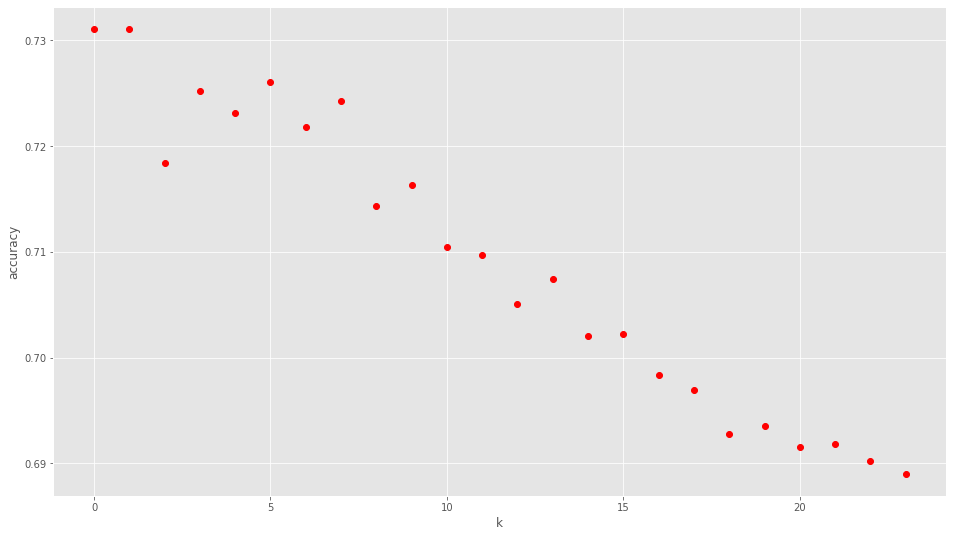

In [10]:
#hago la grafica para k del CV
k_values_cv=[0.73108288, 0.73108288, 0.7184131 , 0.72520824, 0.7231127,0.7260977 , 0.721811  , 0.72428782, 0.71431701, 0.71628555,0.71047494, 0.70971309, 0.7050769 , 0.70739503, 0.7020604 ,0.70221904, 0.69831329, 0.69697978, 0.69278852, 0.69355065,0.69151834, 0.69180442, 0.69024824, 0.68904183]
plt.plot(k_values_cv,'ro')
plt.ylabel('accuracy')
plt.xlabel('k')
plt.xticks([0,5,10,15,20])
plt.show()

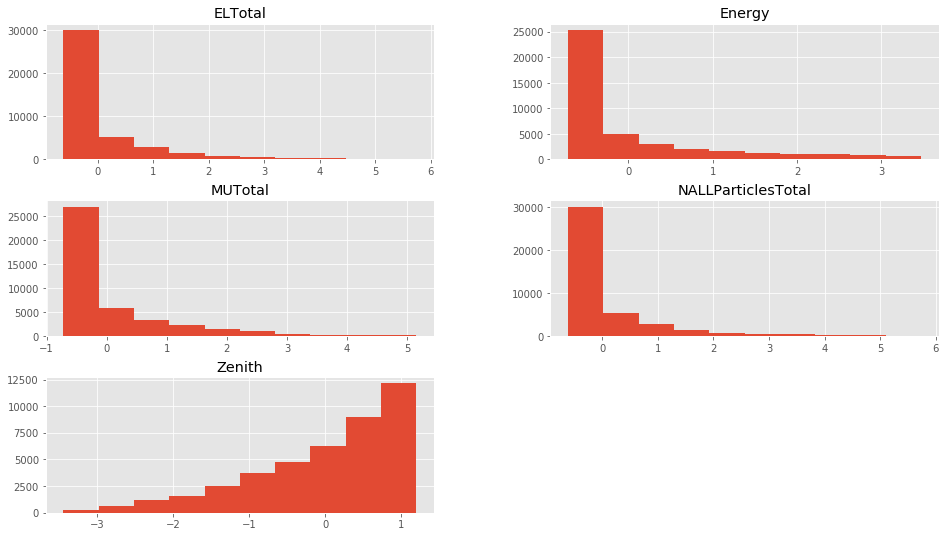

In [11]:
dataframe.hist()
plt.show()
#para ver la distribuciones

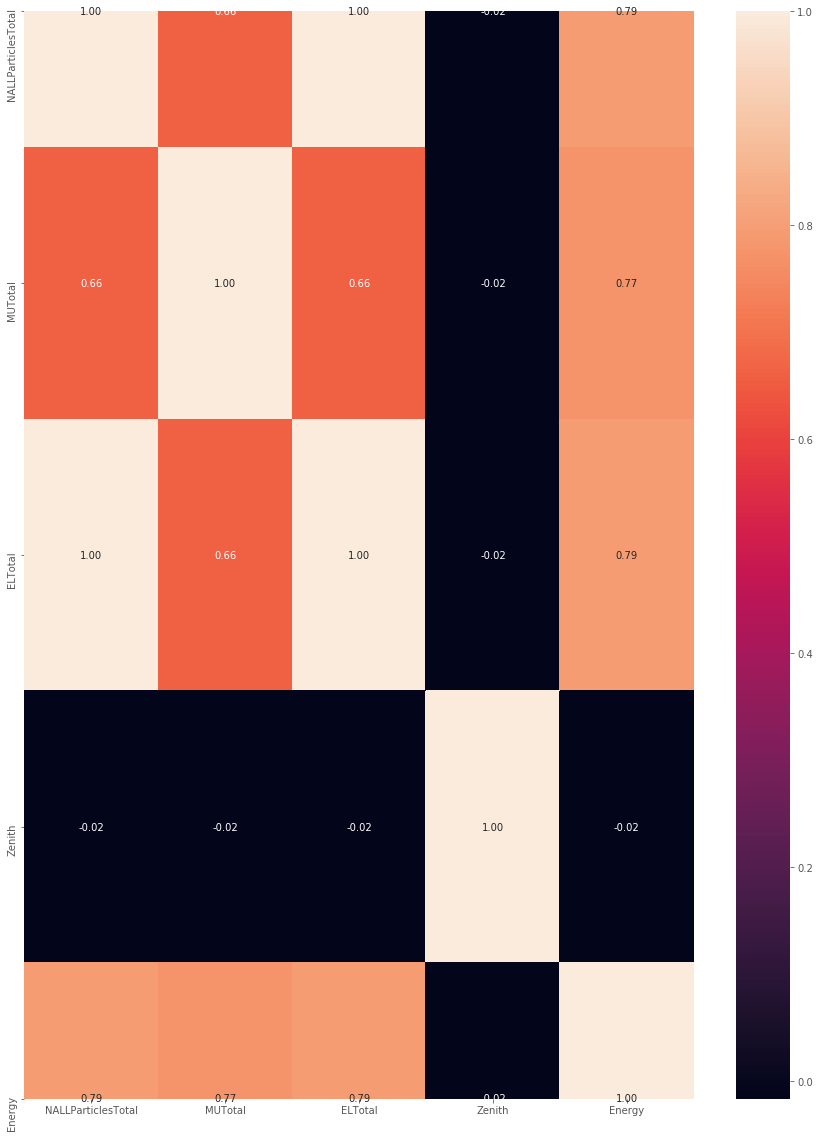

In [12]:
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt


def plot_correlation(data):
    '''
    plot correlation's matrix to explore dependency between features 
    '''
    # init figure size
    rcParams['figure.figsize'] = 15, 20
    fig = plt.figure()
    sns.heatmap(data.corr(), annot=True, fmt=".2f")
    plt.show()
    fig.savefig('corr.png')

# plot correlation & densities
plot_correlation(dataframe)

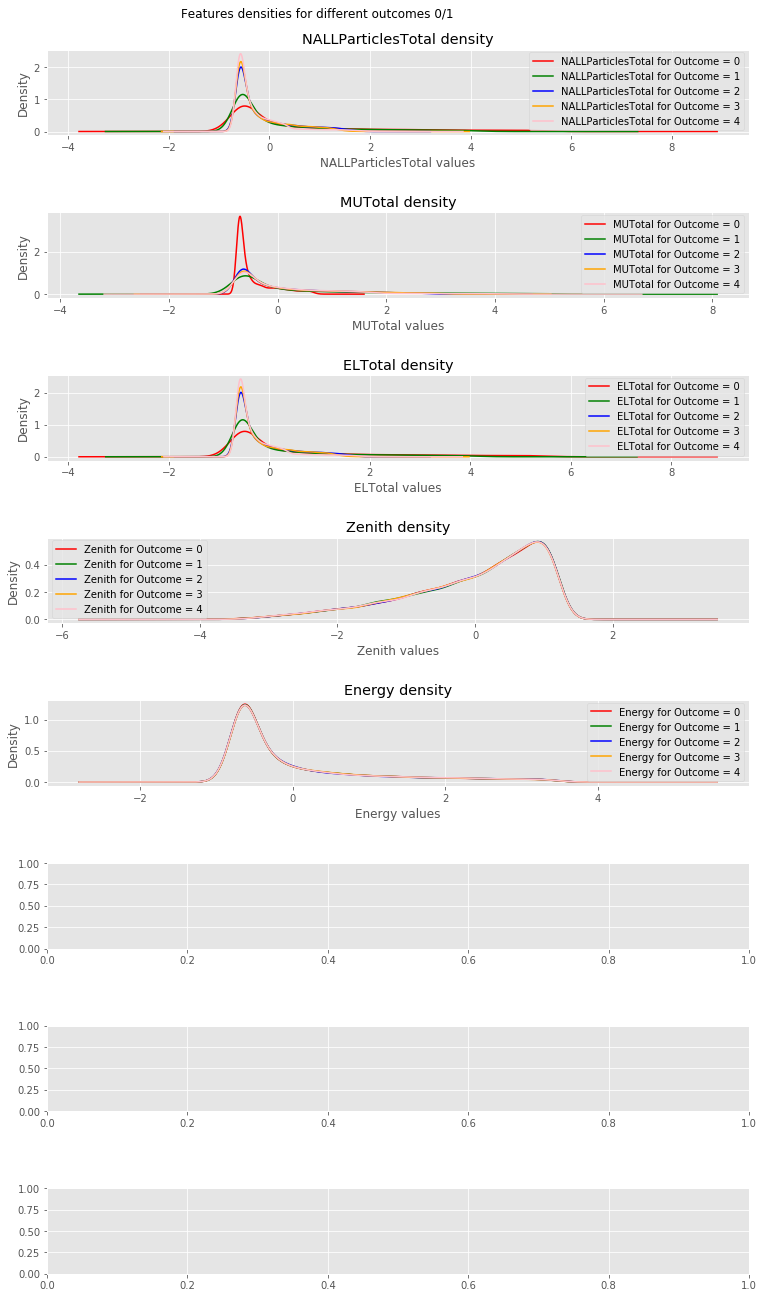

In [13]:
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt


def plot_densities(data):
    '''
    Plot features densities depending on the outcome values
    '''
    # change fig size to fit all subplots beautifully 
    rcParams['figure.figsize'] = 15, 20

    # separate data based on outcome values 
    outcome_0 = data[data['Particle'] == 0]
    outcome_1 = data[data['Particle'] == 1]
    outcome_2 = data[data['Particle'] == 2]
    outcome_3 = data[data['Particle'] == 3]
    outcome_4 = data[data['Particle'] == 4]

    # init figure
    fig, axs = plt.subplots(8, 1)
    fig.suptitle('Features densities for different outcomes 0/1')
    plt.subplots_adjust(left = 0.25, right = 0.9, bottom = 0.1, top = 0.95,
                        wspace = 0.2, hspace = 0.9)

    # plot densities for outcomes
    for column_name in names[:-1]: 
        ax = axs[names.index(column_name)]
        #plt.subplot(4, 2, names.index(column_name) + 1)
        outcome_0[column_name].plot(kind='density', ax=ax, subplots=True, 
                                    sharex=False, color="red", legend=True,
                                    label=column_name + ' for Outcome = 0')
        outcome_1[column_name].plot(kind='density', ax=ax, subplots=True, 
                                     sharex=False, color="green", legend=True,
                                     label=column_name + ' for Outcome = 1')
        outcome_2[column_name].plot(kind='density', ax=ax, subplots=True, 
                                     sharex=False, color="blue", legend=True,
                                     label=column_name + ' for Outcome = 2')
        outcome_3[column_name].plot(kind='density', ax=ax, subplots=True, 
                                     sharex=False, color="orange", legend=True,
                                     label=column_name + ' for Outcome = 3')
        outcome_4[column_name].plot(kind='density', ax=ax, subplots=True, 
                                     sharex=False, color="pink", legend=True,
                                     label=column_name + ' for Outcome = 4')
        ax.set_xlabel(column_name + ' values')
        ax.set_title(column_name + ' density')
        ax.grid('on')
    plt.show()
    fig.savefig('densities.png')


names = list(dataframe_s.columns)

# plot correlation & densities
plot_densities(dataframe_s)

#si en una grafica todas las curvas hacen overlap quiere decir que no separan los tipos de particulas
#asi que en este caso Zenit y energy no explican nada el outcome, por lo que se podrian eliminar
#esto creo que seria algo similar a hacer PCA


C:\Users\HP\Anaconda3\lib\site-packages\seaborn\axisgrid.py:2065: UserWarning: The `size` parameter has been renamed to `height`; pleaes update your code.
  warnings.warn(msg, UserWarning)
C:\Users\HP\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:487: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\Users\HP\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


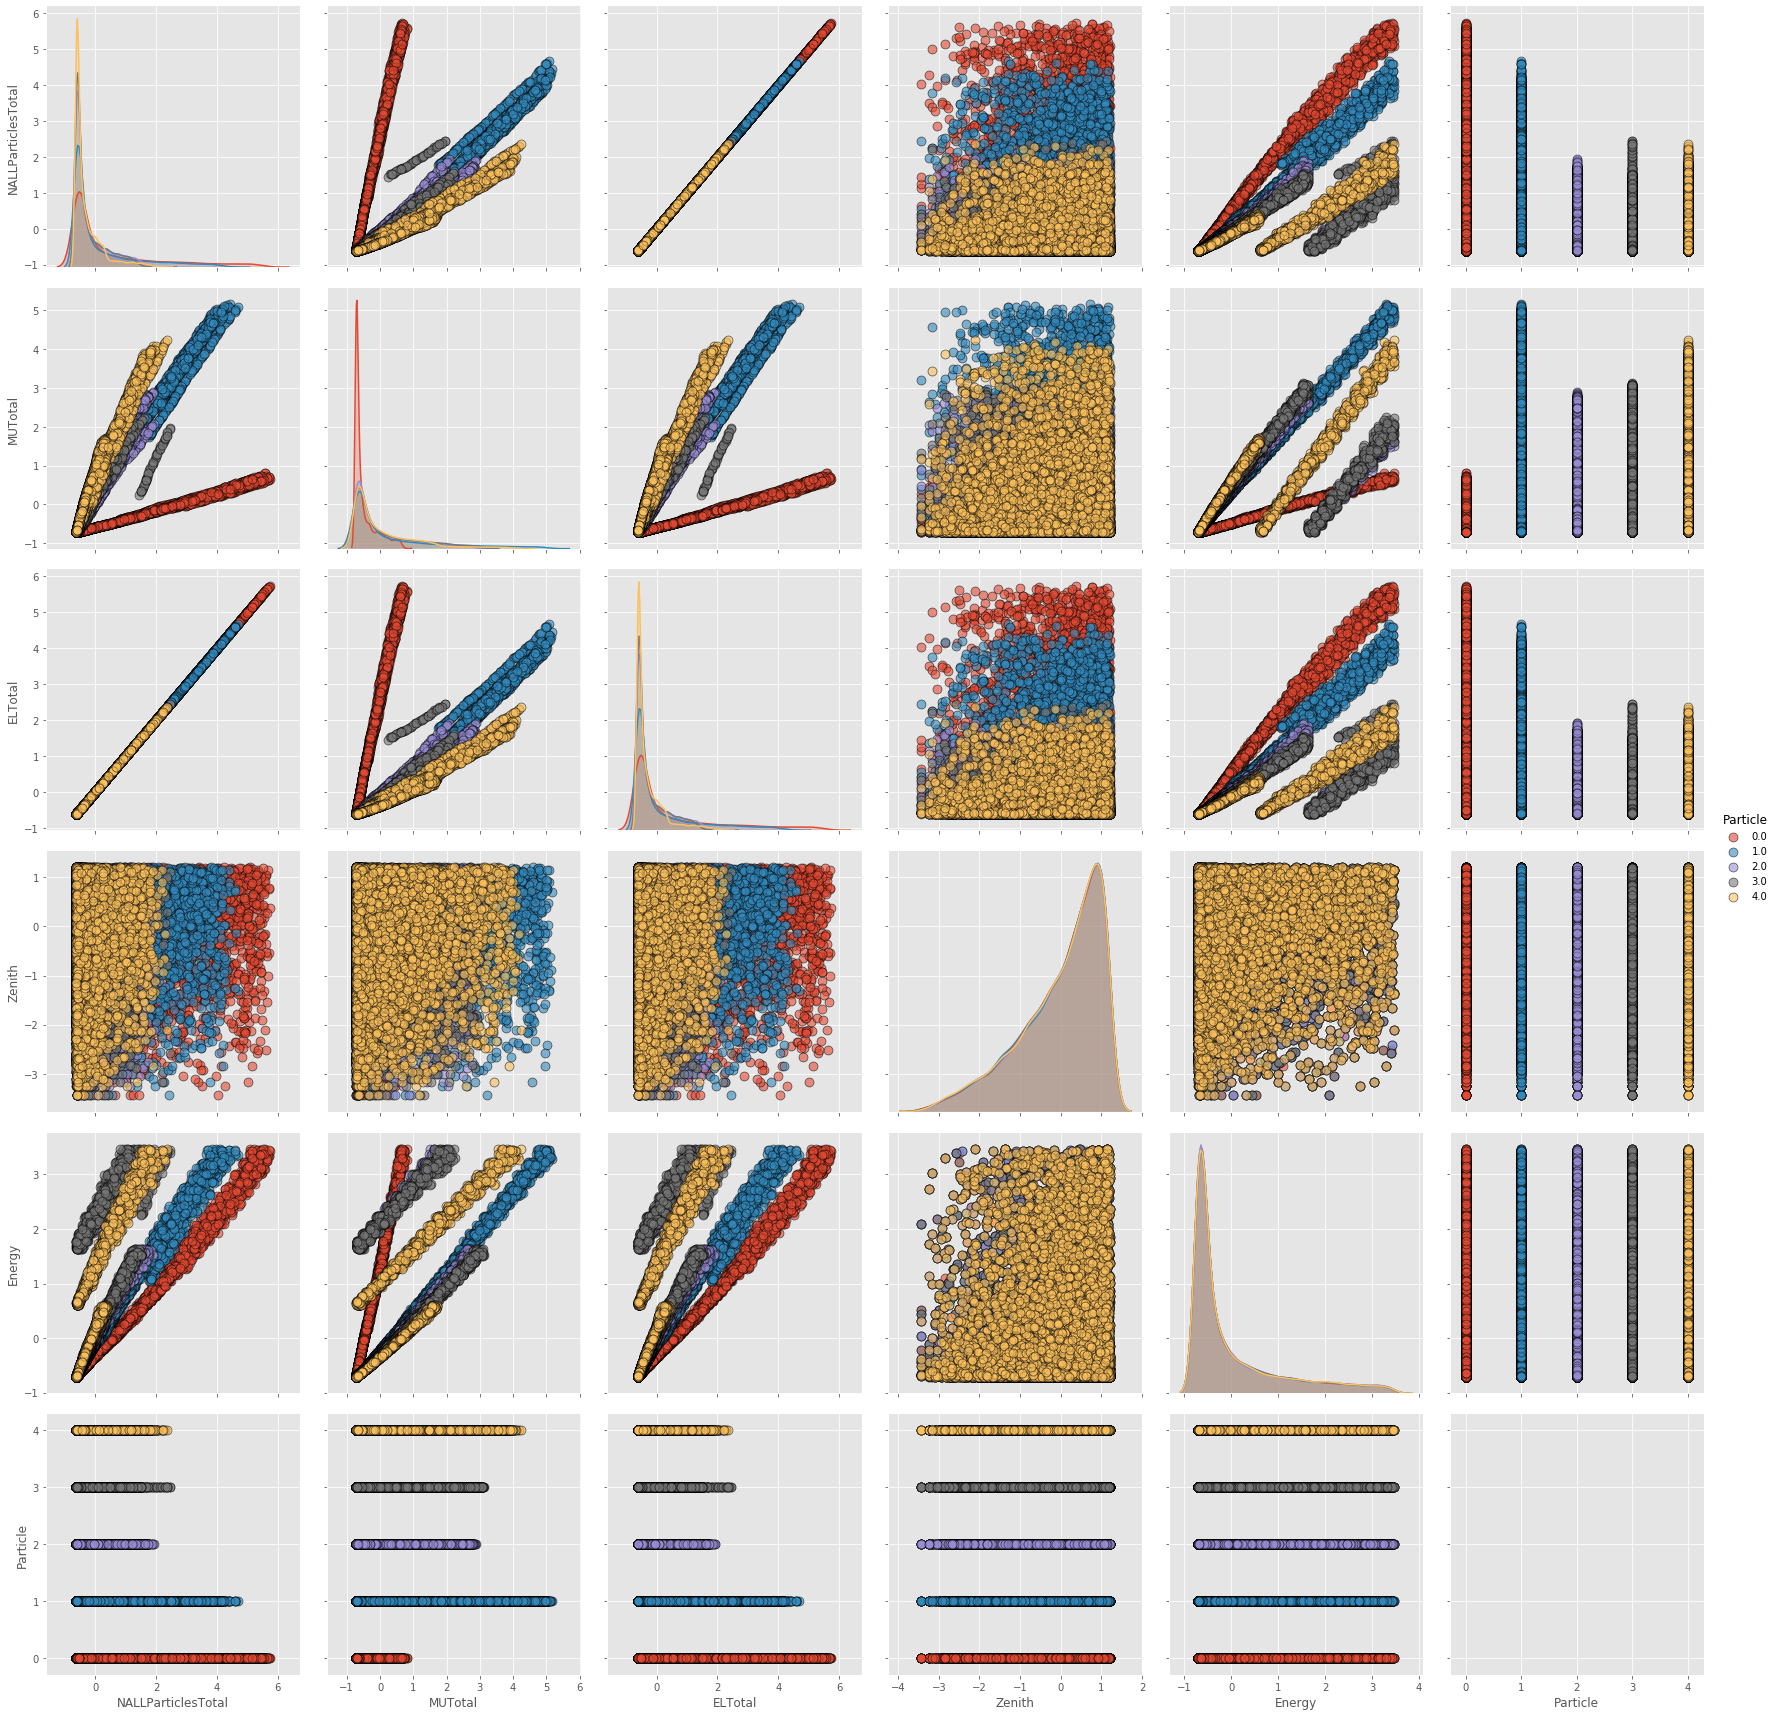

In [14]:
# Create a pair plot colored by continent with a density plot of the # diagonal and format the scatter plots.

#sns.set_style("white")#para que no haya grid
sns.pairplot(dataframe_s, hue = 'Particle', diag_kind = 'kde',
             plot_kws = {'alpha': 0.6, 's': 80, 'edgecolor': 'k'},
             size = 4)
# Title 
#plt.suptitle('Pair Plot of Data',size = 28);
#sns.pairplot(dataframe_s, kind="reg")
#sns.pairplot(dataframe_s, hue = 'Particle')

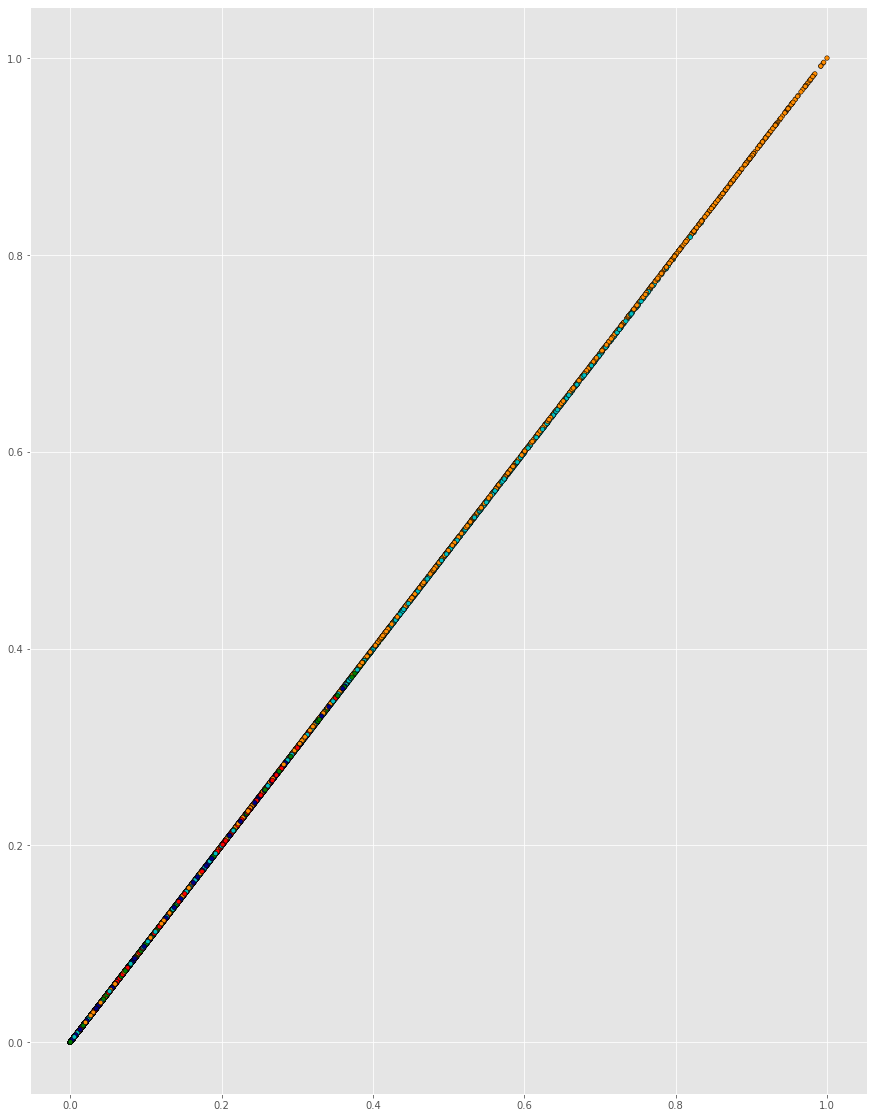

In [15]:
X = X_train_np[:,[0,2]] #aqui esojo las columnas con las que hacer plot
y = y_train_np.astype(int).reshape(len(y_train_np))
cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue', 'darkred', 'darkgreen'])
cmap_bold = ListedColormap(['darkorange', 'c','darkblue','red', 'green'])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,edgecolor='k', s=20)

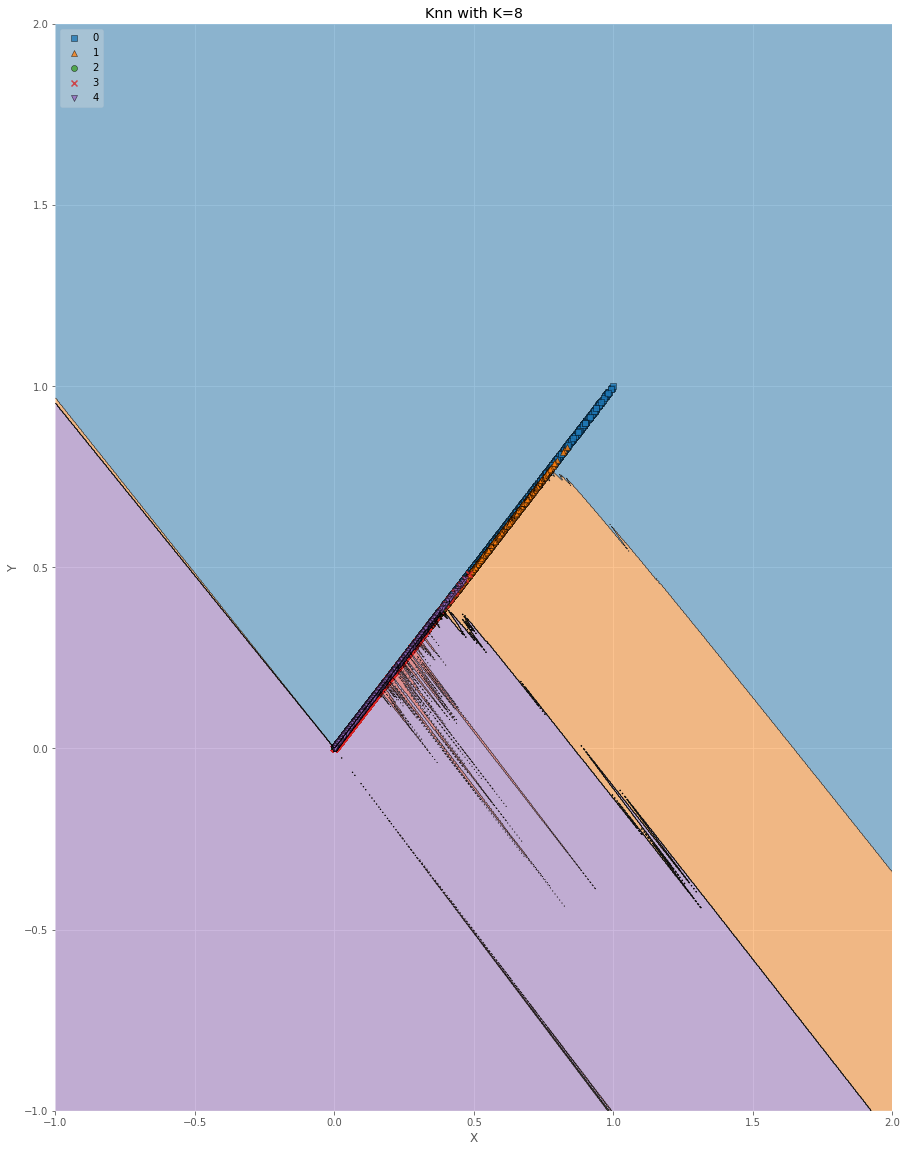

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets, neighbors
from mlxtend.plotting import plot_decision_regions
X_train_np=X_train.to_numpy() #pongo X_train en numpy para trabajar con el 
X_test_np=X_test.to_numpy() #pongo X_test en numpy para trabajar con el 
y_train_np=y_train.to_numpy() #pongo y_train en numpy para trabajar con el 
from sklearn.neighbors import KNeighborsClassifier
def knn_comparison(X_,y_, k): #le paso numpy
 x = X_[:,[0,2]]
 y = y_.astype(int).reshape(len(y_train_np))
 clf = neighbors.KNeighborsClassifier(n_neighbors=k)
 clf.fit(x, y)
# Plotting decision region
 plot_decision_regions(x, y, clf=clf, legend=2)
# Adding axes annotations
 plt.xlabel('X')
 plt.ylabel('Y')
 plt.title('Knn with K='+ str(k))
 plt.show()

knn_comparison(X_train_np,y_train_np,8)

KeyboardInterrupt: 

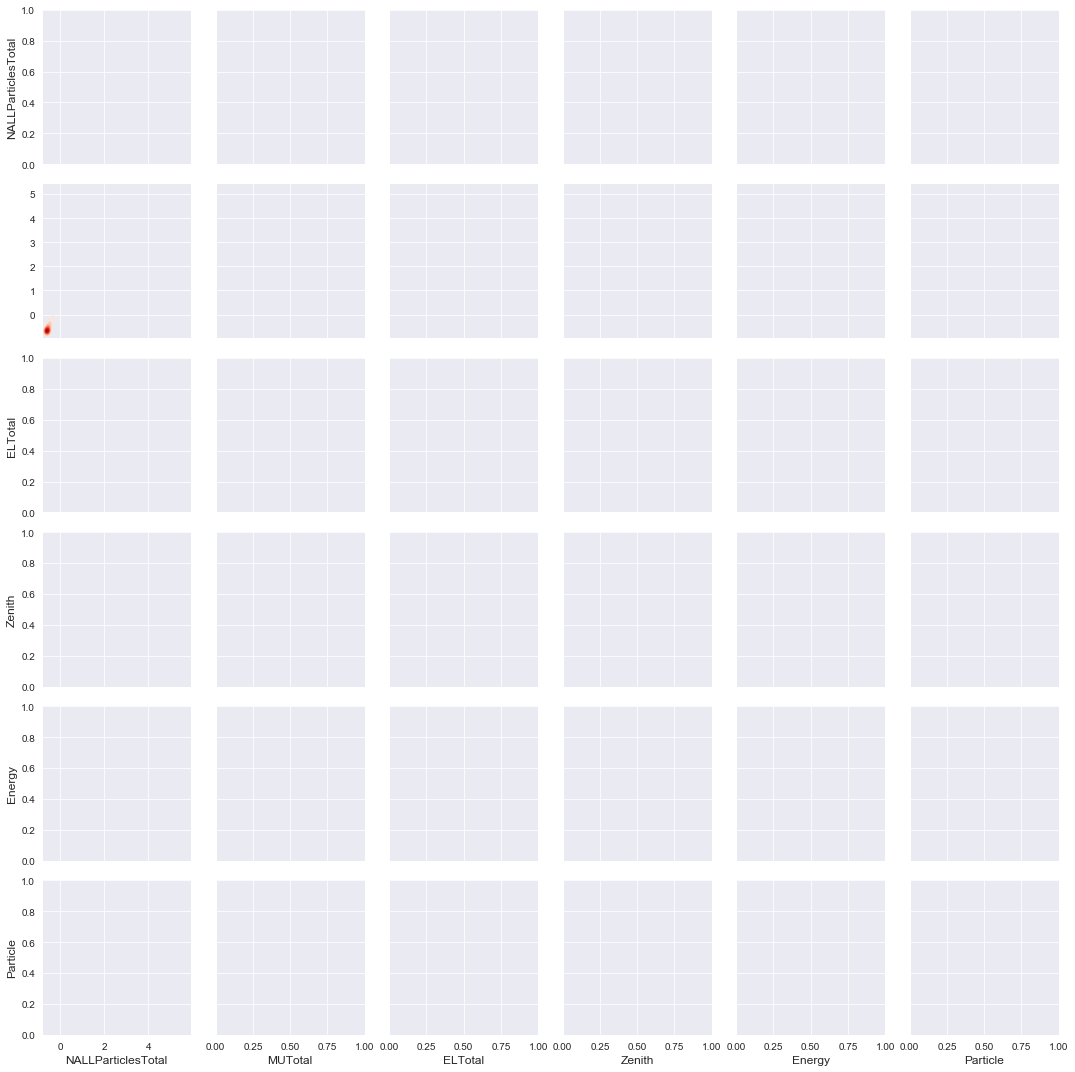

In [132]:
# Create an instance of the PairGrid class.
grid = sns.PairGrid(data= dataframe_s)
# Map a scatter plot to the upper triangle
#grid = grid.map_upper(plt.scatter, color = 'darkred')
# Map a histogram to the diagonal
#grid = grid.map_diag(plt.hist, bins = 10, color = 'darkred', edgecolor = 'k')
# Map a density plot to the lower triangle
grid = grid.map_lower(sns.kdeplot, cmap = 'Reds')

In [ ]:
# Function to calculate correlation coefficient between two arrays
# def corr(x, y, **kwargs):
    
#     # Calculate the value
#     coef = np.corrcoef(x, y)[0][1]
#     # Make the label
#     label = r'$\rho$ = ' + str(round(coef, 2))
    
#     # Add the label to the plot
#     ax = plt.gca()
#     ax.annotate(label, xy = (0.2, 0.95), size = 20, xycoords = ax.transAxes)
    
# # Create a pair grid instance
# grid =sns.PairGrid(data=dataframe_s)

# # Map the plots to the locations
# grid = grid.map_upper(plt.scatter, color = 'darkred')
# grid = grid.map_upper(corr)
# grid = grid.map_lower(sns.kdeplot, cmap = 'Reds')
# grid = grid.map_diag(plt.hist, bins = 10, edgecolor =  'k', color = 'darkred');